In [27]:
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 

In [28]:
import pandas as pd

df = pd.read_csv("Weather,Parent,Money,Decision.csv")
print(df)

   Weather Parent Money  Decision
0    sunny    Yes  Rich    Cinema
1    Sunny     No  Rich    Tennis
2    Windy    Yes  Rich    Cinema
3    Rainy    Yes  Poor    Cinema
4    Rainy     No  Rich   Stay-in
..     ...    ...   ...       ...
79   Rainy     No  Poor    Tennis
80   sunny    Yes  Rich    Tennis
81   Rainy     No  Poor  Shopping
82   sunny    Yes  Rich   Stay-in
83   Rainy     No  Poor  Shopping

[84 rows x 4 columns]


In [8]:
print("\nClass Distribution:\n")
print(df["Decision"].value_counts())


Class Distribution:

Decision
Cinema      32
Tennis      28
Stay-in     12
Shopping    12
Name: count, dtype: int64


In [9]:
X = df.drop("Decision",axis=1)
Y = df["Decision"]
X

,Weather,Parent,Money
0,sunny,Yes,Rich
1,Sunny,No,Rich
2,Windy,Yes,Rich
3,Rainy,Yes,Poor
4,Rainy,No,Rich
...,...,...,...
79,Rainy,No,Poor
80,sunny,Yes,Rich
81,Rainy,No,Poor
82,sunny,Yes,Rich


In [10]:
categorical_features = ["Weather","Parent","Money"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ]
)

In [11]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

In [12]:
pipeline.fit(X,Y)
print("\nTraining Accuracy:", pipeline.score(X,Y))



Training Accuracy: 0.4880952380952381


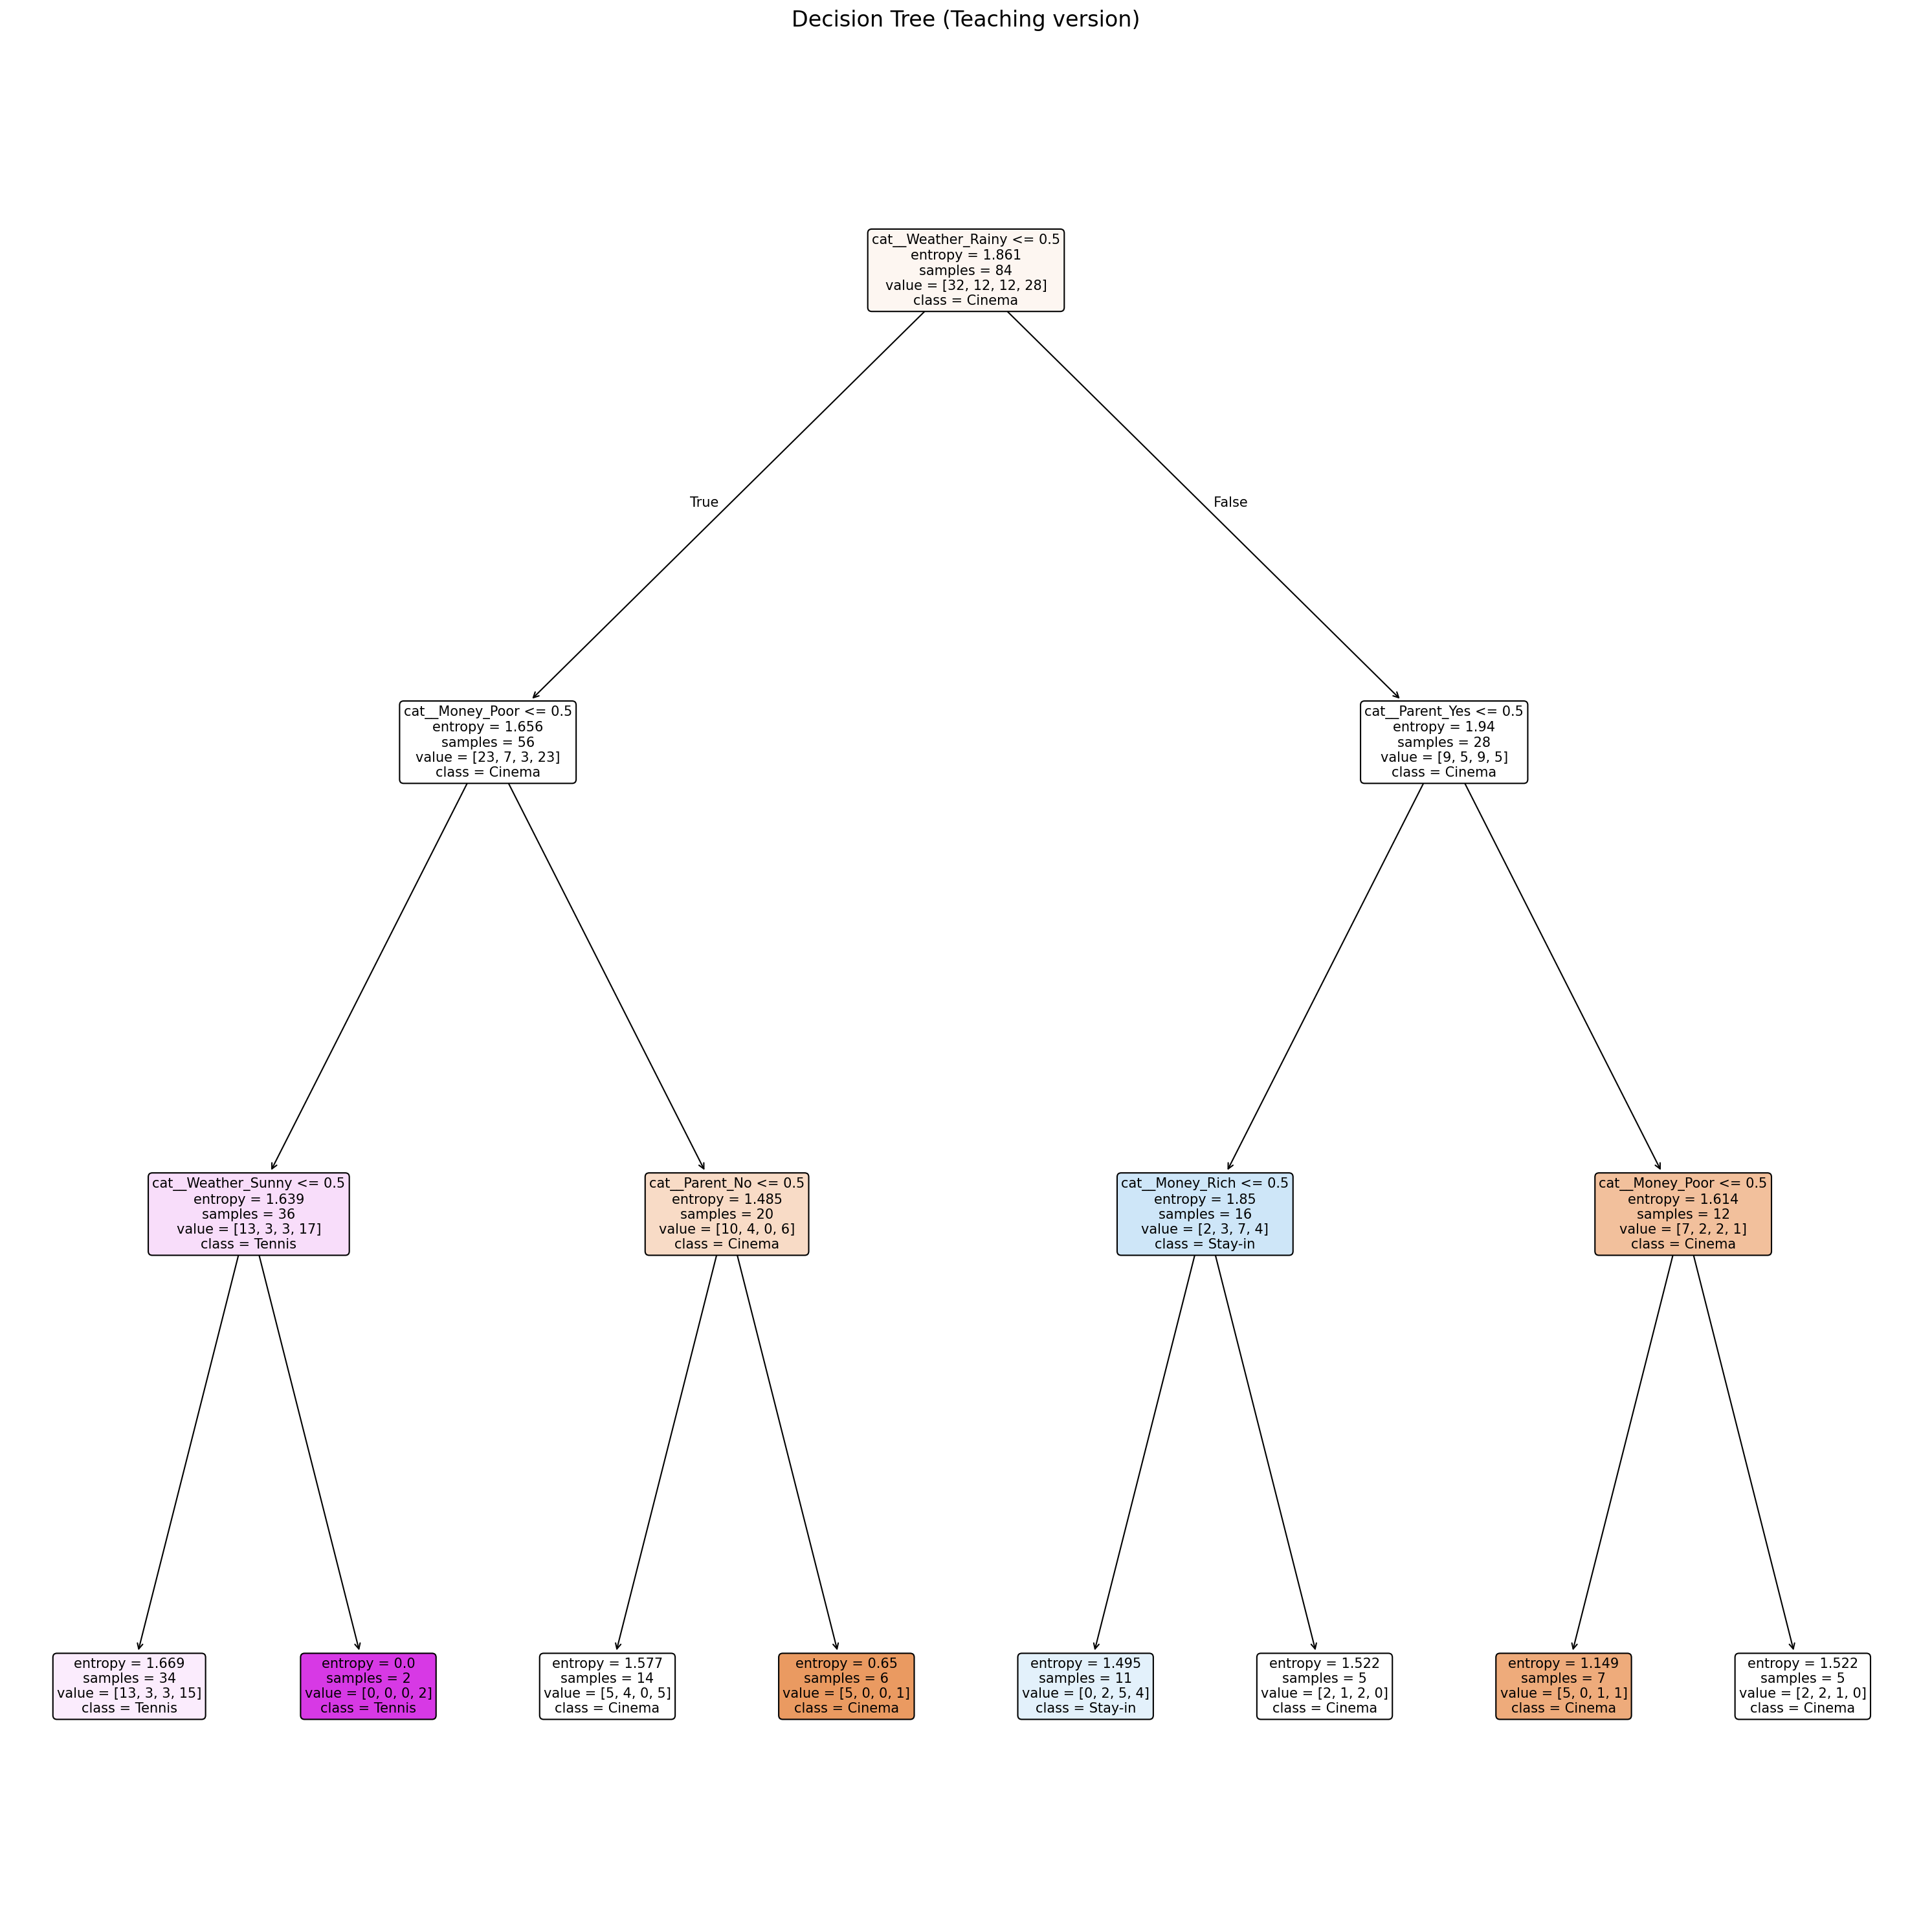

In [13]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
plt.figure(figsize=(20,20), dpi=150)

plot_tree(
    pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=pipeline.named_steps["model"].classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Teaching version)", fontsize=16)
plt.tight_layout()
plt.savefig("clean_decision_tree.png",dpi=300)
plt.show()

In [20]:
def predict_user_input():
    print("\nEnter user Details")
    
    weather = input("Weather (Sunny/Windy/Rainy):")
    parent = input("parent (Yes/No):")
    money = input("Money (Rich/poor):")
    
    user_df = pd.DataFrame({
        "Weather":[weather],
        "Parent":[parent],
        "Money":[money]
    })
    
    prediction = pipeline.predict(user_df)[0]
    probability = pipeline.predict_proba(user_df)
    
    print("\nPredicted Decision:", prediction)
    print("Class Probabilities:")
    
    
    for cls,prob in zip(pipeline.named_steps["model"].classes_,probability[0]):
        print(f"{cls}: {round(prob*100,2)}%")


In [21]:
predict_user_input()


Enter user Details


Weather (Sunny/Windy/Rainy): Sunny
parent (Yes/No): Yes
Money (Rich/poor): Rich



Predicted Decision: Tennis
Class Probabilities:
Cinema: 0.0%
Shopping: 0.0%
Stay-in: 0.0%
Tennis: 100.0%


In [29]:
x = df.drop("Decision", axis=1)
y = df["Decision"]


X_train,X_test,Y_train,Y_test = train_test_split(
    x,y, 
    test_size=0.2, 
    random_state=42
) 
Y_test

73      Tennis
0       Cinema
58      Cinema
22      Cinema
12      Tennis
70      Cinema
10      Tennis
18      Tennis
4      Stay-in
65      Tennis
40    Shopping
47     Stay-in
35      Cinema
81    Shopping
55    Shopping
54     Stay-in
33      Cinema
Name: Decision, dtype: str

In [31]:
pipeline.fit(X_train,Y_train)
print("\n Training Accuracy:", pipeline.score(x,y))


 Training Accuracy: 0.4880952380952381


In [32]:
pred=pipeline.predict(X_test)

In [33]:
acc=accuracy_score(Y_test,pred)
acc

0.4117647058823529